## Modelamiento Microclima con downscalling 

In [ ]:
# Instalamos las librerías necesarias
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Cargamos las rutas de acceso a los archivos ráster
tn_path = "E:\Proyectos_Python\Climatico\CMIP6_2.5_min\wc2.1_2.5m_tmin_BCC-CSM2-MR_ssp245_2021-2040.tif"
tx_path = "E:\Proyectos_Python\Climatico\CMIP6_2.5_min\wc2.1_2.5m_tmax_BCC-CSM2-MR_ssp245_2021-2040.tif"

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
C:\Users\danny\AppData\Local\Temp\ipykernel_13680\3878130973.py:2: SyntaxWarning: invalid escape sequence '\P'
  tn_path = "E:\Proyectos_Python\Climatico\CMIP6_2.5_min\wc2.1_2.5m_tmin_BCC-CSM2-MR_ssp245_2021-2040.tif"
C:\Users\danny\AppData\Local\Temp\ipykernel_13680\3878130973.py:3: SyntaxWarning: invalid escape sequence '\P'
  tx_path = "E:\Proyectos_Python\Climatico\CMIP6_2.5_min\wc2.1_2.5m_tmax_BCC-CSM2-MR_ssp245_2021-2040.tif"


In [ ]:
# Abrimos ambos archivos ráster y leemos los datos
with rasterio.open(tn_path) as tn_src:
    tn = tn_src.read(1)
    profile = tn_src.profile  # guardamos metadata

with rasterio.open(tx_path) as tx_src:
    tx = tx_src.read(1)


In [ ]:
# Calculamos la temperatura media diaria / en este caso sería (tn+tx)/2
tmedia = (tn + tx) / 2

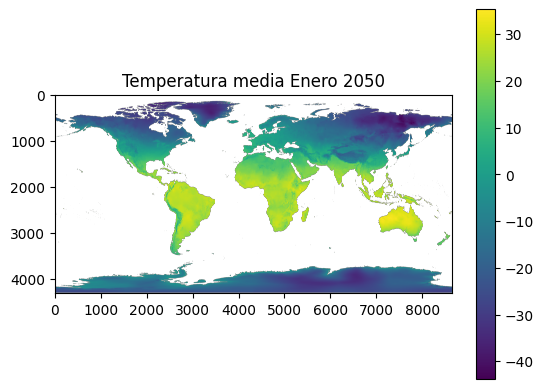

In [ ]:
# Visualizamos los resultados obtenidos 
plt.imshow(tmedia)
plt.colorbar()
plt.title("Temperatura media Enero 2050")
plt.show()

In [ ]:
# Guardamos este resultado en un nuevo archivo ráster 
with rasterio.open("tmedia_01.tif", "w", **profile) as dst:
    dst.write(tmedia, 1)

## Estructura para los 12 meses del año  / Ojo que el raster de wordclim ya contiene las bandas para los 12 meses


In [ ]:
import os
carpeta = "E:/Proyectos_Python/Climatico/CMIP6_2.5_min"
print("Archivos en la carpeta:")
for f in os.listdir(carpeta):
    if f.endswith(".tif"):
        print(f"  - {f}")

Archivos en la carpeta:
  - wc2.1_2.5m_tmax_BCC-CSM2-MR_ssp245_2021-2040.tif
  - wc2.1_2.5m_tmin_BCC-CSM2-MR_ssp245_2021-2040.tif


In [ ]:
import rasterio
import numpy as np

base_dir = "E:/Proyectos_Python/Climatico/CMIP6_2.5_min"
tn_path = os.path.join(base_dir, "wc2.1_2.5m_tmin_BCC-CSM2-MR_ssp245_2021-2040.tif")
tx_path = os.path.join(base_dir, "wc2.1_2.5m_tmax_BCC-CSM2-MR_ssp245_2021-2040.tif")

with rasterio.open(tn_path) as tn_src:
    tn = tn_src.read()          # (bandas, alto, ancho) → 12 bandas
    profile = tn_src.profile

with rasterio.open(tx_path) as tx_src:
    tx = tx_src.read()

# Procesa cada mes (banda)
for mes in range(12):
    tmedia = (tn[mes] + tx[mes]) / 2
    output_name = f"tmedia_{mes+1:02d}.tif"
    with rasterio.open(output_name, "w", **profile) as dst:
        dst.write(tmedia, 1)

## Construcción del raster climático base ( Unión de las 12 varibales)

In [ ]:
import rasterio
import numpy as np
import glob

# --- Paso 1: definir los nombres de archivos que quieres procesar ---
# Opción A: lista explícita (más clara si son pocos)
nombres_deseados = [
    "tmedia_01.tif", "tmedia_02.tif", "tmedia_03.tif",
    "tmedia_04.tif", "tmedia_05.tif", "tmedia_06.tif",
    "tmedia_07.tif", "tmedia_08.tif", "tmedia_09.tif",
    "tmedia_10.tif", "tmedia_011.tif", "tmedia_12.tif"
]

# --- Paso 2: buscar solo los que existen en el directorio ---
archivos = [arch for arch in glob.glob("tmedia_*.tif") if arch in nombres_deseados]
archivos.sort()   # orden ascendente (numérico)

# --- Paso 3: leer los archivos ---
stack = []
profile = None   # guardaremos el perfil del primer archivo

for archivo in archivos:
    with rasterio.open(archivo) as src:
        data = src.read(1)
        stack.append(data)
        if profile is None:
            profile = src.profile   # guardamos el perfil para luego

# --- Paso 4: verificar que todos tengan la misma forma (evitar el error) ---
shapes = [arr.shape for arr in stack]
if len(set(shapes)) != 1:
    # Si hay formas distintas, recortamos al tamaño mínimo común
    print("Advertencia: los archivos tienen diferentes dimensiones. Recortando al tamaño mínimo.")
    min_rows = min(s[0] for s in shapes)
    min_cols = min(s[1] for s in shapes)
    stack = [arr[:min_rows, :min_cols] for arr in stack]

# --- Paso 5: apilar y mostrar resultado ---
stack = np.stack(stack)
print(stack.shape)   # (n_archivos, alto, ancho)

In [ ]:
## Guardamos el archivo multibanda
profile.update(count=12)

with rasterio.open("tmedia_stack.tif", "w", **profile) as dst:
    dst.write(stack)

In [ ]:
# Calculamos el promedio anual
tmedia_anual = stack.mean(axis=0)

In [ ]:
# Guardamos el resultado del promedio anual 
profile.update(count=1)

with rasterio.open("tmedia_anual.tif", "w", **profile) as dst:
    dst.write(tmedia_anual, 1)

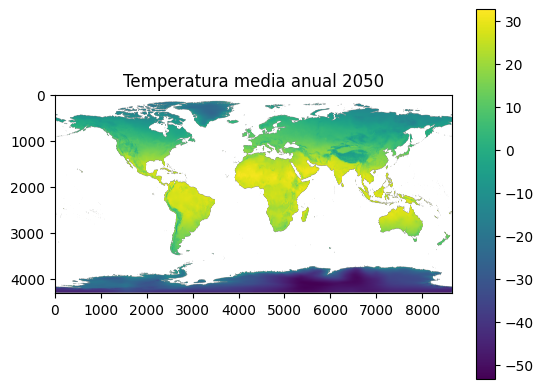

In [ ]:
# Visualizamos o ploteamos el resultado 
import matplotlib.pyplot as plt

plt.imshow(tmedia_anual)
plt.colorbar()
plt.title("Temperatura media anual 2050")
plt.show()

# Recortamos al área de interés - Pichincha ejemplo

In [1]:
# Importamos las librerías necesarias para trabajar con datos geoespaciales
import geopandas as gpd
%pip install rioxarray



Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Verificamos que la librería rioxarray se haya instalado correctamente
import rioxarray
import xarray as xr

# Opcional: verificar la versión
print(rioxarray.__version__)

0.22.0


In [ ]:
# Importamos la ruta del archivo
zona = gpd.read_file("E:\Proyectos_Python\Climatico\Zona_Estudio\Pichincha.shp")

# Validamos que el shape esté correctamente estructurado
print(zona.geometry.is_valid)  # True si son válidas
print(zona.crs)                # Muestra el sistema de coordenadas


0    True
dtype: bool
EPSG:32717


<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\danny\AppData\Local\Temp\ipykernel_14436\3469520721.py:2: SyntaxWarning: invalid escape sequence '\P'
  zona = gpd.read_file("E:\Proyectos_Python\Climatico\Zona_Estudio\Pichincha.shp")


In [ ]:
try:
    zona = gpd.read_file(r"E:\Proyectos_Python\Climatico\Zona_Estudio\Pichincha.shp")
    print("Shapefile cargado correctamente")
    print(f"CRS: {zona.crs}")
    raster = rioxarray.open_rasterio(r"E:\Proyectos_Python\Climatico\tmedia_anual.tif")
    print(f"Raster CRS: {raster.rio.crs}")
    # Reproject if needed
    if zona.crs != raster.rio.crs:
        zona = zona.to_crs(raster.rio.crs)
    recorte = raster.rio.clip(zona.geometry)
    recorte.rio.to_raster("tmedia_anual_recortado.tif", compress='LZW')
    print("Recorte guardado exitosamente")
except Exception as e:
    print(f"Error: {e}")

Shapefile cargado correctamente
CRS: EPSG:32717
Raster CRS: EPSG:4326
Recorte guardado exitosamente


## Resampleo de los pixel tanto del dem como clima 

In [ ]:
import rasterio
from rasterio.enums import Resampling

# Abrir temperatura (referencia)
with rasterio.open("tmedia_anual_recortado.tif") as ref:
    ref_profile = ref.profile
    ref_shape = ref.shape
    ref_transform = ref.transform

# Abrir DEM
with rasterio.open(r"E:\Proyectos_Python\Climatico\DEM\Cut_Dem.tif") as dem_src:
    dem_data = dem_src.read(1)

    dem_resampled = dem_src.read(
        1,
        out_shape=ref_shape,
        resampling=Resampling.average
    )

    dem_transform = dem_src.transform

In [ ]:
# Guardamos el dem resampleado - ajustado para que tenga la misma resolución y extensión que el ráster de temperatura
profile = ref_profile.copy()

with rasterio.open("dem_ajustado.tif", "w", **profile) as dst:
    dst.write(dem_resampled, 1)

In [ ]:
# Aplicamos la correción termica al DEM utilizando una fórmula simple de lapse rate (ejemplo: -6.5°C por cada 1000m)
import numpy as np

# cargar temperatura
with rasterio.open("tmedia_anual_recortado.tif") as src:
    temp = src.read(1)
    profile = src.profile

# usar DEM ajustado
dem = dem_resampled

# elevación promedio
z0 = np.nanmean(dem)  # OJO IMPORTANTE LIMPIAR LOS VALORES SIN DATO

# gradiente térmico
gamma = 0.0065

# corrección
temp_corr = temp - gamma * (dem - z0)

In [ ]:
# Guradmos el resultado corregido
with rasterio.open("tmedia_microclima.tif", "w", **profile) as dst:
    dst.write(temp_corr, 1)

In [ ]:
## Validacion
print("Temp original:", np.nanmean(temp))
print("Temp corregida:", np.nanmean(temp_corr))

Temp original: 15.818286
Temp corregida: -79.30717552705504


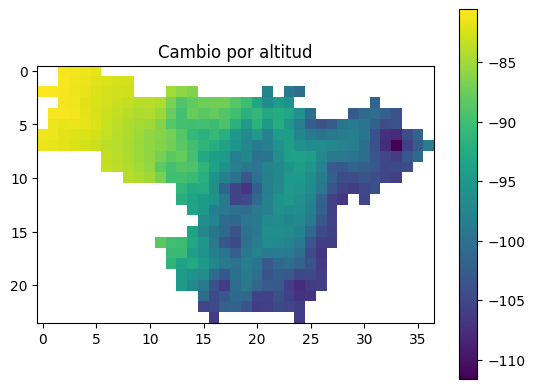

In [ ]:
# Visualización de la diferencia entre la temperatura original y la corregida
import matplotlib.pyplot as plt

plt.imshow(temp_corr - temp)
plt.colorbar()
plt.title("Cambio por altitud")
plt.show()

In [ ]:
print(np.nanmin(dem), np.nanmax(dem))

-32768 4884


## LIMPIAMOS EL DEM DE LOS VALORES SIN DATO


In [ ]:
# Limpiamos el DEM de valores sin dato para evitar que afecten el análisis
dem_resampled = dem_resampled.astype("float32")

dem_resampled[dem_resampled == -32768] = np.nan

In [ ]:
# recalculamos la elevación promedio después de limpiar los valores sin dato
z0 = np.nanmean(dem_resampled)
print("Elevación promedio:", z0)

Elevación promedio: 2338.0425


In [ ]:
# Recalculatmos la corrección térmica con el DEM limpio
gamma = 0.0065

temp_corr = temp - gamma * (dem_resampled - z0)

In [ ]:
# Validamos la información obtenida después de limpiar el DEM
print("Temp original:", np.nanmean(temp))
print("Temp corregida:", np.nanmean(temp_corr))

Temp original: 15.818286
Temp corregida: 15.771688


In [ ]:
# Guardamos el resultado como un nuevo archivo ráster
with rasterio.open("tmedia_microclima2.tif", "w", **profile) as dst:
    dst.write(temp_corr, 1)

In [ ]:
# Comprobamos que se guardó la infomración correctamente 
with rasterio.open("tmedia_microclima2.tif") as src:
    data = src.read(1)

print(np.nanmean(data))

15.771688


## Radiación solar (modelo básico físico)

In [ ]:
# Partimos de nuestro DEM - Calculamos tanto la pendiente como la orientación del terreno a partir del DEM

import numpy as np
import rasterio

with rasterio.open(r"E:\Proyectos_Python\Climatico\DEM\Cut_Dem.tif") as src:
    dem = src.read(1).astype("float32")
    profile = src.profile
    transform = src.transform

In [ ]:
# Obtenemos las gradientes en x y en y para calcular pendiente y orientación
# Resolución espacial
xres = transform[0]  # 0 indica la resolución en x 
yres = -transform[4] # 4 indica la resolución en y (negativa porque el origen está en la esquina superior izquierda)

# Gradientes
dz_dx = np.gradient(dem, axis=1) / xres
dz_dy = np.gradient(dem, axis=0) / yres


In [ ]:
# Pendiente 
slope = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))

In [ ]:
# Orientación 
aspect = np.arctan2(-dz_dx, dz_dy)
aspect = np.where(aspect < 0, 2 * np.pi + aspect, aspect)

### Modelo de radiación solar

In [ ]:
# radiación depende del ángulo de incidencia solar
solar_zenith = np.radians(45)  # ángulo del sol
solar_azimuth = np.radians(0)  # norte

In [ ]:
# Cálculo de radiación
radiation = (
    np.cos(solar_zenith) * np.cos(slope) +
    np.sin(solar_zenith) * np.sin(slope) * np.cos(solar_azimuth - aspect)
)

In [ ]:
# Limpiamos los valores sin dato de la radiación para evitar que existan errores 
radiation[radiation < 0] = 0

# Normalizamos
radiation_norm = (radiation - np.nanmin(radiation)) / (np.nanmax(radiation) - np.nanmin(radiation))

In [ ]:
# Guardamos el raster
with rasterio.open("radiacion.tif", "w", **profile) as dst:
    dst.write(radiation_norm, 1)

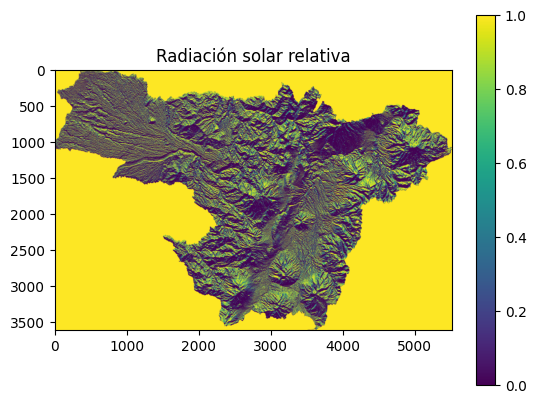

In [ ]:
# Visualizamos los datos de radiación 
import matplotlib.pyplot as plt

plt.imshow(radiation_norm)
plt.colorbar()
plt.title("Radiación solar relativa")
plt.show()

# Donde los valores = a 0 indican áreas sin radiación (sombra) y los valores cercanos a 1 indican áreas con máxima radiación (expuestas al sol)

## Reproyectamos la radicación para que esta coincida o tenga la misma resolución que la temperatura

In [ ]:
# Reproyectamos la radiación para que tenga la misma resolución y extensión que el ráster de temperatura corregida por altitud (tmedia_microclima2.tif) para poder combinar ambos factores en un modelo de microclima más completo
from rasterio.warp import reproject, Resampling
import numpy as np
import rasterio

# Abrir temperatura (referencia)
with rasterio.open("tmedia_microclima2.tif") as ref:
    temp_corr = ref.read(1)
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = temp_corr.shape
    profile = ref.profile

# Abrir radiación (alta resolución)
with rasterio.open("radiacion.tif") as src:
    radiation_resampled = np.empty(ref_shape, dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=radiation_resampled,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.average
    )

In [ ]:
# Normalizamos nuevamente
radiation_norm = (
    radiation_resampled - np.nanmin(radiation_resampled)
) / (
    np.nanmax(radiation_resampled) - np.nanmin(radiation_resampled)
)

In [ ]:
# Aplicamos el ajuste termico
factor = 3  # puedes ajustar

temp_final = temp_corr + factor * (radiation_norm - 0.5)

In [ ]:
# Guardamos el resultado final combinando la corrección por altitud y el efecto de la radiación solar
with rasterio.open("tmedia_microclima_final.tif", "w", **profile) as dst:
    dst.write(temp_final, 1)

In [ ]:
# validamos
print("Temp final promedio:", np.nanmean(temp_final))

Temp final promedio: 14.615252


### Integrar al modelo de temperatura

In [ ]:
# Ajuste térmico final combinando la corrección por altitud y el efecto de la radiación solar

factor = 3  # intensidad (ajustable)
temp_final = temp_corr + factor * (radiation_norm - 0.5)

### Integración de la variable uso y cobertura del suelo 

In [ ]:
# Cargamos el archivo de uso de suelo y verificamos los valores no data 
import rasterio
import numpy as np

with rasterio.open(r"E:\Proyectos_Python\Climatico\Land_Cover_corte\Land_cover.tif") as src:
    lc = src.read(1)
    lc_profile = src.profile
    nodata_value = src.nodata

print("Valor NoData:", nodata_value)
print("Valores únicos:", np.unique(lc))

Valor NoData: None
Valores únicos: [-1.04543591e+34 -5.36775460e+26 -6.98829478e-18 -1.77251147e-32
 -8.49032533e-33 -8.38215634e-33  0.00000000e+00  5.75933669e-43
  5.77334967e-43  2.33624480e-41  2.35418142e-41  2.36539181e-41
  2.37211804e-41  2.37772323e-41  2.38332843e-41  2.39005466e-41
  1.75753376e-38  1.89528700e-38  1.89668620e-38  2.09872429e-38
  1.40218339e-35  8.66080103e-29  3.54049094e-28  3.62173437e-28
  3.63243869e-28  6.87925228e-28  7.36074247e-28  7.77442452e-28
  7.86364130e-28  7.98986674e-28  9.24975860e-17  7.15355662e-15
  1.36425593e-12  1.47945024e-12  1.55249251e-12  1.79686994e-12
  1.79885447e-12  1.80367526e-12  3.35886874e-12  6.11326811e-09
  7.52940541e-05  1.00000000e+01  2.00000000e+01  3.00000000e+01
  4.00000000e+01  5.00000000e+01  6.00000000e+01  7.00000000e+01
  8.00000000e+01  9.00000000e+01  1.00000000e+02  1.13066650e+02
  1.22780151e+02  1.23812622e+02  1.24875244e+02  1.26340332e+02
  1.29279297e+02  1.31375244e+02  1.34732666e+02  1.464

In [ ]:
# Convertir a float + limpiar NoData
lc = lc.astype("float32")

# Si el raster tiene valor NoData definido
if nodata_value is not None:
    lc[lc == nodata_value] = np.nan

# Por seguridad (casos comunes)
lc[lc == 0] = np.nan
lc[lc == 255] = np.nan

In [ ]:
# Craamo el ráster de efecto térmico del uso de suelo (ejemplo simple basado en categorías comunes)
lc_effect = np.full_like(lc, np.nan, dtype="float32")

# Vegetación (enfría)
lc_effect[(lc == 10) | (lc == 20)] = -1.5
lc_effect[(lc == 30) | (lc == 40)] = -1.0

#  Urbano (calienta)
lc_effect[lc == 50] = 2.0

# Suelo desnudo
lc_effect[lc == 60] = 1.0

# Agua
lc_effect[lc == 80] = -0.5

In [ ]:
# Validamos los datos obtenidos 
print("Valores efecto:", np.unique(lc_effect[~np.isnan(lc_effect)]))

Valores efecto: [-1.5 -1.  -0.5  1.   2. ]


In [ ]:
# Reproyectamos el ráster de uso de suelo para que tenga la misma resolución y extensión que el ráster de temperatura corregida por altitud  para poder combinar ambos factores en un modelo de microclima más completo
from rasterio.warp import reproject, Resampling

# raster referencia (temperatura final)
with rasterio.open(r"E:\Proyectos_Python\Climatico\tmedia_microclima_final.tif") as ref:
    temp_final = ref.read(1)
    ref_shape = temp_final.shape
    ref_transform = ref.transform
    ref_crs = ref.crs
    profile = ref.profile

# crear array destino
lc_resampled = np.empty(ref_shape, dtype=np.float32)

# reproyección
with rasterio.open(r"E:\Proyectos_Python\Climatico\Land_Cover_corte\Land_cover.tif") as src:
    reproject(
        source=rasterio.band(src, 1),
        destination=lc_resampled,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.mode  # clave para clases
    )

In [ ]:
# Limpiamos el resampleado de valores sin dato
lc_resampled = lc_resampled.astype("float32")

# limpiar valores raros
lc_resampled[lc_resampled == nodata_value] = np.nan
lc_resampled[lc_resampled == 0] = np.nan
lc_resampled[lc_resampled == 255] = np.nan

In [ ]:
# Reclasificamos el ráster resampleado para asignar el efecto térmico basado en las categorías de uso de suelo
lc_effect_resampled = np.full_like(lc_resampled, np.nan, dtype="float32")

# vegetación
lc_effect_resampled[(lc_resampled == 10) | (lc_resampled == 20)] = -1.5
lc_effect_resampled[(lc_resampled == 30) | (lc_resampled == 40)] = -1.0

# urbano
lc_effect_resampled[lc_resampled == 50] = 2.0

# suelo desnudo
lc_effect_resampled[lc_resampled == 60] = 1.0

# agua
lc_effect_resampled[lc_resampled == 80] = -0.5

In [ ]:
# Integramos al modelo termico final el efecto del uso de suelo sumando ambos factores (corrección por altitud + efecto de uso de suelo)
factor_lc = 1.5  # puedes calibrar

temp_final_lc = temp_final + factor_lc * np.nan_to_num(lc_effect_resampled)

In [ ]:
# Guardamos el resultado final combinando la corrección por altitud y el efecto de la radiación solar
with rasterio.open("tmedia_microclima_lc.tif", "w", **profile) as dst:
    dst.write(temp_final_lc, 1)

In [ ]:
# Validación final
print("Temp antes:", np.nanmean(temp_final))
print("Temp después:", np.nanmean(temp_final_lc))

Temp antes: 14.615252
Temp después: 12.8304205


In [ ]:
# Variación de cambbio OJO aquí es importante revisar que los cambios sean razonables y no existan errores en la integración de los factores Esperado:
#zonas frías: -2 a -3°C  # resultado razonable para áreas con mucha vegetación o agua
# zonas calientes: +1 a +2°C  # resultado razonable para áreas urbanas o suelo desnudo
# se espera estos resultados


print("Min cambio:", np.nanmin(temp_final_lc - temp_final))
print("Max cambio:", np.nanmax(temp_final_lc - temp_final))

Min cambio: -2.25
Max cambio: 3.000001


## Predicción de Escenarios Futuros

### Usamos IPCC (CMIP6 vía WorldClim) 2030 – 2050 – 2100 == SSP2-4.5 (realista)

In [7]:
## Cargamos los datos 
import rasterio
import numpy as np

# temperatura mínima futura
with rasterio.open(r"E:\Proyectos_Python\Climatico\CMIP6_2.5_min_2040_2060 Futuro\wc2.1_2.5m_tmin_BCC-CSM2-MR_ssp245_2041-2060.tif") as src:
    tmin = src.read(1)
    profile = src.profile # Aquí definimos el perfil para usarlo posteriormente al guardar los resultados

# temperatura máxima futura
with rasterio.open(r"E:\Proyectos_Python\Climatico\CMIP6_2.5_min_2040_2060 Futuro\wc2.1_2.5m_tmax_BCC-CSM2-MR_ssp245_2041-2060.tif") as src:
    tmax = src.read(1)

In [8]:
# Obtenemos la temperatura media

tmedia_futuro = (tmax + tmin) / 2



In [9]:
# manejamos los valores sin dato (en este caso asumimos que valores menores a -100°C son erróneos y los convertimos a NaN)
tmedia_futuro[(tmin < -100) | (tmax < -100)] = np.nan

In [10]:
# Ajustar profile antes de guardar
profile.update(
    dtype=rasterio.float32,
    count=1
)

In [11]:
# Guardamos el raster resultante 

with rasterio.open("tmedia_futuro.tif", "w", **profile) as dst:
    dst.write(tmedia_futuro.astype("float32"), 1)

In [12]:
# Validacion
print(np.nanmean(tmedia_futuro))

-4.340923


### Calculamos la anomalía climática

In [ ]:
# Alineamos primero el ráster
from rasterio.warp import reproject, Resampling

with rasterio.open("tmedia_anual_recortado.tif") as ref:
    ref_shape = ref.shape
    ref_transform = ref.transform
    ref_crs = ref.crs

delta_resampled = np.empty(ref_shape, dtype=np.float32)

with rasterio.open("tmedia_futuro.tif") as src:
    reproject(
        source=rasterio.band(src, 1),
        destination=delta_resampled,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.bilinear
    )

delta_T = delta_resampled - temp_actual

In [26]:
import os

print(os.listdir())

['CMIP6_2.5_min', 'CMIP6_2.5_min_2040_2060 Futuro', 'DEM', 'dem_ajustado.tif', 'dem_ajustado.tif.aux.xml', 'Land_Cover_corte', 'Modelamiento_Microclima.ipynb', 'Prueba', 'radiacion.tif', 'radiacion.tif.aux.xml', 'terrascope_download_20260401_100649', 'terrascope_download_20260401_102056', 'terrascope_download_20260401_102309', 'terrascope_download_20260401_102315', 'tmedia_01.tif', 'tmedia_02.tif', 'tmedia_03.tif', 'tmedia_04.tif', 'tmedia_05.tif', 'tmedia_06.tif', 'tmedia_07.tif', 'tmedia_08.tif', 'tmedia_09.tif', 'tmedia_10.tif', 'tmedia_11.tif', 'tmedia_12.tif', 'tmedia_anual.tif', 'tmedia_anual.tif.aux.xml', 'tmedia_anual_recortado.tif', 'tmedia_anual_recortado.tif.aux.xml', 'tmedia_futuro.tif', 'tmedia_microclima.tif', 'tmedia_microclima.tif.aux.xml', 'tmedia_microclima2.tif', 'tmedia_microclima2.tif.aux.xml', 'tmedia_microclima_final.tif', 'tmedia_microclima_final.tif.aux.xml', 'tmedia_microclima_lc.tif', 'tmedia_microclima_lc.tif.aux.xml', 'tmedia_stack.tif', 'tmedia_stack.tif.a

In [29]:
# cargar modelo calibrado
with rasterio.open(r"E:\Proyectos_Python\Climatico\tmedia_microclima_lc.tif") as src:  ## tmedia_microclima_calibrado o _lc 
    temp_calibrado = src.read(1)
    profile = src.profile

# integrar cambio climático
temp_futuro_micro = temp_calibrado + delta_T

In [30]:
# Guardamos la simulación para 20250 con el modelo de microclima ajustado por uso de suelo

with rasterio.open("tmedia_microclima_2050.tif", "w", **profile) as dst:
    dst.write(temp_futuro_micro.astype("float32"), 1)

In [32]:
# Validación  siempre los valores esperados deberán teber un aumento de temperatura en el futuro con respecto al presente, pero el aumento no debe ser exagerado (ejemplo: un aumento promedio de 1 a 3°C dependiendo del escenario climático y la región)
print("Actual:", np.nanmean(temp_calibrado))
print("Futuro:", np.nanmean(temp_futuro_micro))    

Actual: 12.8304205
Futuro: 13.466403


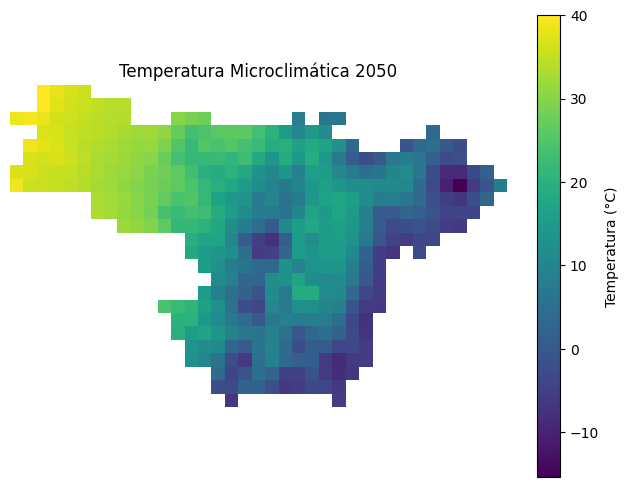

In [36]:
# PLoteo 
import rasterio
import matplotlib.pyplot as plt

with rasterio.open(r"E:\Proyectos_Python\Climatico\tmedia_microclima_2050.tif") as src:
    temp = src.read(1)

plt.figure(figsize=(8,6))
img = plt.imshow(temp)
plt.colorbar(img, label="Temperatura (°C)")
plt.title("Temperatura Microclimática 2050")
plt.axis("off")
plt.show()

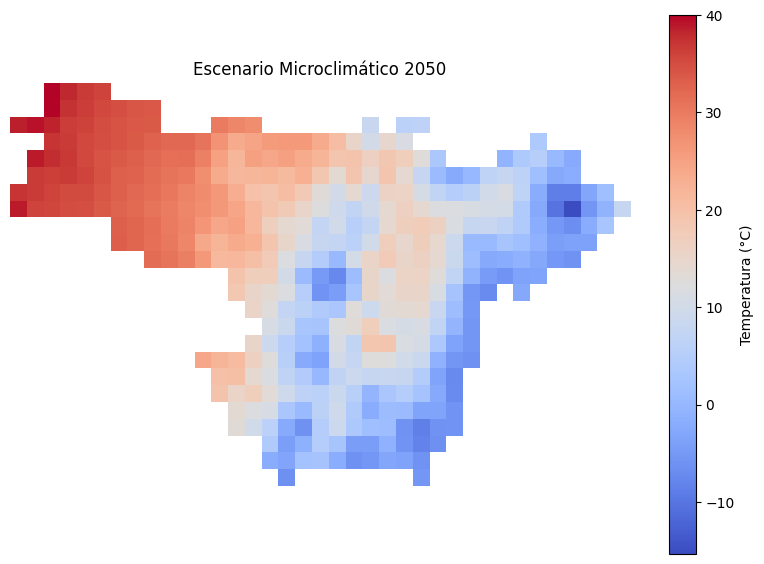

In [37]:
plt.figure(figsize=(10,7))

img = plt.imshow(temp, cmap="coolwarm")  # azul-frío / rojo-calor
plt.colorbar(img, label="Temperatura (°C)")

plt.title("Escenario Microclimático 2050")
plt.axis("off")

plt.show()

## MAPA DE RIESGO TERMICO


In [40]:
# CARGAMOS MAPA TEMPERATURA FUTURO
import rasterio
import numpy as np

with rasterio.open(r"E:\Proyectos_Python\Climatico\tmedia_microclima_2050.tif") as src:
    temp = src.read(1)
    profile = src.profile

In [41]:
# Clasificamos el riesgo 
riesgo = np.zeros_like(temp, dtype="int32")

riesgo[temp < 10] = 1
riesgo[(temp >= 10) & (temp < 15)] = 2
riesgo[(temp >= 15) & (temp < 20)] = 3
riesgo[(temp >= 20) & (temp < 25)] = 4
riesgo[temp >= 25] = 5

In [43]:
# eliminamos valores NODATA 
riesgo[np.isnan(temp)] = 0


In [46]:
# Guardamos el mapra de riesgo térmico
profile.update(dtype=rasterio.int32, nodata=-9999)

# Asegúrate de reemplazar los NaN en 'riesgo' por -9999 antes de escribir
riesgo = np.nan_to_num(riesgo, nan=-9999).astype(np.int32)

with rasterio.open("riesgo_termico.tif", "w", **profile) as dst:
    dst.write(riesgo, 1)

In [48]:
# Riesgo relativo
profile.update(dtype=rasterio.int32, nodata=-9999)

# Asegúrate de reemplazar los NaN en 'riesgo' por -9999 antes de escribir
riesgo = np.nan_to_num(riesgo, nan=-9999).astype(np.int32)

with rasterio.open("riesgo_termico.tif", "w", **profile) as dst:
    dst.write(riesgo, 1)